In [7]:
import bw2data as bd
import bw2calc as bc
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
bd.projects.set_current("bw25_plca_grid_expansion")

In [3]:

m = (
    'ecoinvent-3.10',
    'EF v3.1 no LT',
    'climate change no LT',
    'global warming potential (GWP100) no LT'
)

In [4]:
database_names = [db for db in bd.databases if "markets" in db]
database_names


['grid_components_markets_Base_2023',
 'grid_components_markets_Base_2025',
 'grid_components_markets_Base_2030',
 'grid_components_markets_Base_2035',
 'grid_components_markets_Base_2037',
 'grid_components_markets_Base_2040',
 'grid_components_markets_RCP26_2023',
 'grid_components_markets_RCP26_2025',
 'grid_components_markets_RCP26_2030',
 'grid_components_markets_RCP26_2035',
 'grid_components_markets_RCP26_2037',
 'grid_components_markets_RCP26_2040',
 'grid_components_markets_RCP19_2023',
 'grid_components_markets_RCP19_2025',
 'grid_components_markets_RCP19_2030',
 'grid_components_markets_RCP19_2035',
 'grid_components_markets_RCP19_2037',
 'grid_components_markets_RCP19_2040']

In [5]:
results = []

for db_name in database_names:
    db = bd.Database(db_name)
    
    activity = [act for act in db if "market for Gas insulated switchgear" in act['name']] #example
    activity = activity[0]
    
    # Create LCA object
    fu = {activity: 1}
    lca = bc.LCA(fu, m)
    lca.lci()
    lca.lcia()
    
    parts = db_name.split("_")
    scenario = parts[3]
    year = int(parts[4])
    score = lca.score
    
    results.append({"Scenario": scenario, "Year": year, "GWI Score": score})
    print(f"{db_name}: {lca.score}")    

grid_components_markets_Base_2023: 856704.6278885788
grid_components_markets_Base_2025: 816823.8263655623
grid_components_markets_Base_2030: 696873.0914600961
grid_components_markets_Base_2035: 577651.2348849764
grid_components_markets_Base_2037: 498921.5039144031
grid_components_markets_Base_2040: 420210.5672440983
grid_components_markets_RCP26_2023: 856704.6278885788
grid_components_markets_RCP26_2025: 775046.8429901887
grid_components_markets_RCP26_2030: 574938.3715477886
grid_components_markets_RCP26_2035: 414122.87576638523
grid_components_markets_RCP26_2037: 334327.8503400858
grid_components_markets_RCP26_2040: 254113.60641370976
grid_components_markets_RCP19_2023: 856704.6278885788
grid_components_markets_RCP19_2025: 731848.2400753921
grid_components_markets_RCP19_2030: 481300.79867367673
grid_components_markets_RCP19_2035: 320738.29698863573
grid_components_markets_RCP19_2037: 243440.41620935805
grid_components_markets_RCP19_2040: 166095.5762990212


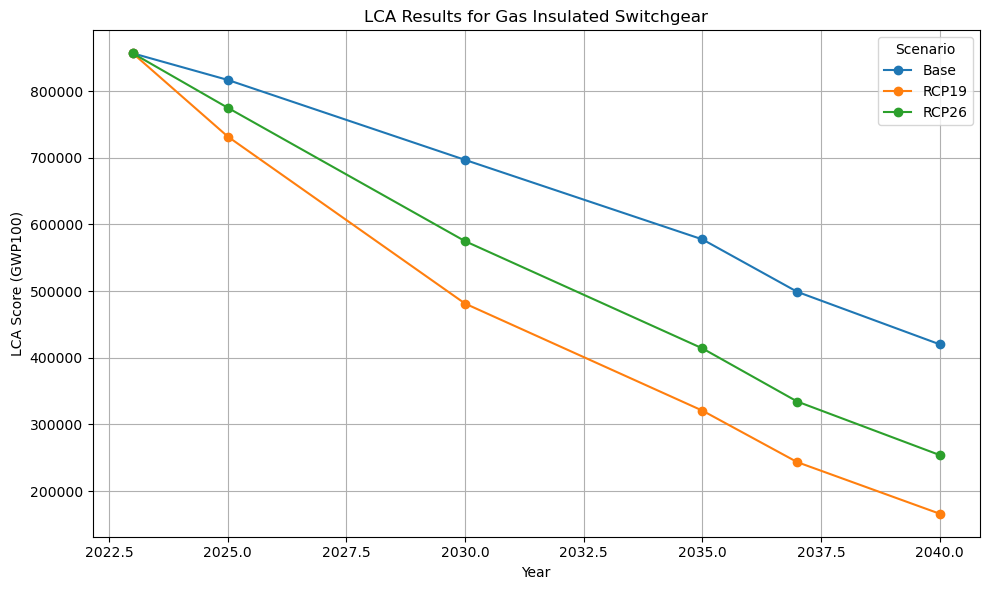

In [10]:
df_results = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
for scenario, group in df_results.groupby("Scenario"):
    plt.plot(group["Year"], group["GWI Score"], marker='o', label=scenario)

plt.title("LCA Results for Gas Insulated Switchgear")
plt.xlabel("Year")
plt.ylabel("LCA Score (GWP100)")
plt.legend(title="Scenario")
plt.grid(True)
plt.tight_layout()
plt.show()